In [1]:
print("all ok")

all ok


input   output
Text -> Text
Text -> Image
Image -> Text
Image -> Image(not required)
Text-> Audio
Audio -> Text
Audio -> Audio(not required)
text -> video
video -> text

In [2]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI

load_dotenv()

llm = AzureChatOpenAI(
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
)

f:\Full_Stack_GenerativeAI_And_Agentic_AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# import os
# ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
# if ANTHROPIC_API_KEY:
#     os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

# from langchain_anthropic import ChatAnthropic

# llm = ChatAnthropic(
#     model="claude-haiku-4-5-20251001",
#     temperature=0
# )

In [4]:
message = llm.invoke("azure open ai")

In [5]:
message

AIMessage(content="Azure OpenAI Service is a cloud-based platform provided by Microsoft that allows you to integrate OpenAI's powerful language and AI models into your applications, websites, and workflows using Azure's infrastructure. This service provides enterprise-level security, scalability, compliance, and easy integration with other Azure services.\n\nSome of the key features and use cases include:\n\n---\n\n### **Key Features:**\n1. **Access to OpenAI Models**:\n   - Supports OpenAI’s advanced models like GPT-4, GPT-3.5, Codex, and DALLE.\n   - These models can handle natural language understanding (NLU), natural language generation (NLG), and code generation tasks.\n\n2. **Managed API Services**:\n   - Provides REST APIs for developers to interact with OpenAI models.\n   - Ideal for integrating AI capabilities into your applications with ease and scale.\n\n3. **Enterprise-Grade Security**:\n   - Azure provides compliance with key industry standards (e.g., GDPR, ISO 27001, SOC 

### Text to Image

In [13]:
from openai import AzureOpenAI
import os
import base64
from IPython.display import Image, display

client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version="2025-04-01-preview"
)
IMAGE_DEPLOYMENT = "gpt-image-2"

In [14]:
result = client.images.generate(
    model=IMAGE_DEPLOYMENT,
    prompt="Draw a cute fuzzy cat with an umbrella",
    size="1024x1024"
)

In [15]:
image_base64 = result.data[0].b64_json

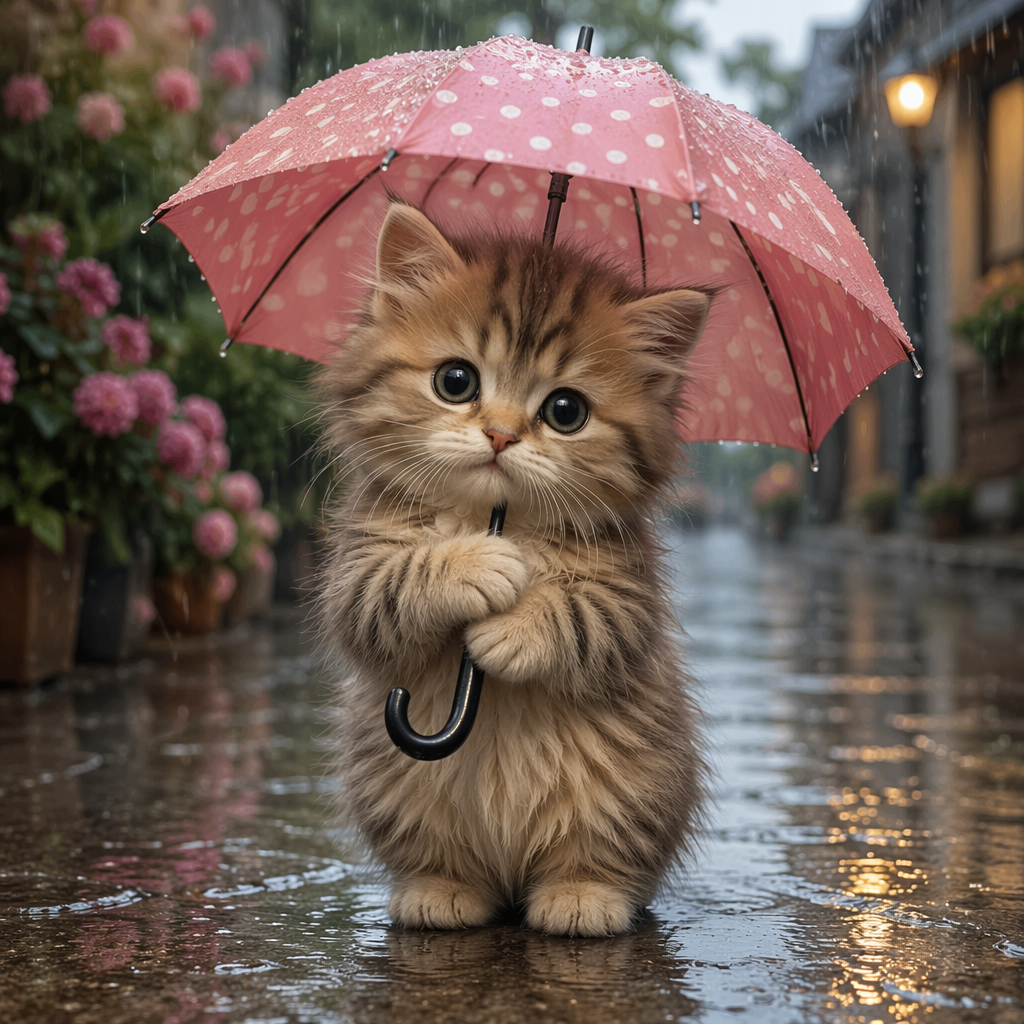

In [16]:
display(
    Image(
        data=base64.b64decode(image_base64),
        width=400
    )
)

### Image to Text

In [17]:
def encode_image(image_path):
    with open(image_path,"rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [20]:
base64_image = encode_image(r"F:\Full_Stack_GenerativeAI_And_Agentic_AI\LLMS _SLM_Multimodal_LLM_Via_Different_Apis\cat.png")

In [21]:
base64_image

'...'

In [22]:
from langchain_core.messages import HumanMessage

message = HumanMessage(
    content=[
        {"type": "text", "text": "What is in this image?"},
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{base64_image}"
            },
        }
    ]
)

In [23]:
response = llm.invoke([message])

In [24]:
print(response.content)

This image depicts an adorable, fluffy orange kitten holding a small umbrella. The kitten has a cute expression, with big round eyes and a little smile, and the background suggests it's raining lightly. The umbrella is teal in color and provides a cozy and charming vibe to the scene.


#### Text to text: free

In [ ]:
import os
GROQ_API_KEY = os.getenv ("GROQ_API_KEY")  # This will return None if the environment variable is not set
if GROQ_API_KEY:
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [ ]:
from langchain_groq import ChatGroq
load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.getenv("GROQ_API_KEY")
)

In [32]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to Hindi. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]

In [33]:
ai_msg = llm.invoke(messages)

In [34]:
print(ai_msg.content)

<think>
Okay, the user wants to translate "I love programming." into Hindi. Let me start by breaking down the sentence. "I" is "मैं" in Hindi. "Love" can be translated as "प्यार करता हूँ" for a male speaker or "प्यार करती हूँ" for a female. Since the user didn't specify gender, I'll go with the masculine form as it's the default in many contexts. 

Now, "programming" – the direct translation would be "प्रोग्रामिंग", but sometimes it's better to use the Hindi term "कोडिंग" depending on the context. However, "प्रोग्रामिंग" is more accurate here because it's the direct translation of the English word. 

Putting it all together: "मैं प्रोग्रामिंग प्यार करता हूँ।" Wait, the structure in Hindi is Subject + Object + Verb. So it should be "मैं प्रोग्रामिंग को प्यार करता हूँ।" Adding "को" after the object for proper sentence structure.

Let me double-check. "I love programming" – yes, "मैं प्रोग्रामिंग को प्यार करता हूँ।" That sounds correct. Alternatively, "मैं प्रोग्रामिंग से प्यार करता हूँ।"

#### Image to text: free

In [35]:
llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="meta-llama/llama-4-scout-17b-16e-instruct"
)

In [36]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe this image in detail."
        },
        {
            "type": "image_url",
            "image_url": {
                "url": "https://www.coolutils.com/blog/wp-content/uploads/2025/06/jpg.png"
            }
        }
    ]
)

In [37]:
response = llm.invoke([message])

In [38]:
response

AIMessage(content='The image presents a concise and informative visual representation of what a JPG file is, featuring a title and an icon.\n\n* **Title**\n\t+ The title "What Is a JPG File?" is prominently displayed in large black text at the top of the image.\n\t+ It serves as a clear heading that immediately conveys the topic of the image.\n* **Icon**\n\t+ Below the title, a square icon with rounded corners is centered in the image.\n\t+ The icon features a gradient background that transitions from blue to purple, pink, orange, and yellow, creating a visually appealing effect.\n\t+ A white outline of a document with a folded corner is superimposed over the gradient background.\n\t+ Inside the document outline, a simple line drawing of a mountain range with a sun or moon is depicted.\n\t+ At the bottom of the document outline, the letters "JPG" are written in white text.\n\nIn summary, the image effectively communicates the topic of JPG files through a clear title and a recognizable 

In [39]:
print(response.content)

The image presents a concise and informative visual representation of what a JPG file is, featuring a title and an icon.

* **Title**
	+ The title "What Is a JPG File?" is prominently displayed in large black text at the top of the image.
	+ It serves as a clear heading that immediately conveys the topic of the image.
* **Icon**
	+ Below the title, a square icon with rounded corners is centered in the image.
	+ The icon features a gradient background that transitions from blue to purple, pink, orange, and yellow, creating a visually appealing effect.
	+ A white outline of a document with a folded corner is superimposed over the gradient background.
	+ Inside the document outline, a simple line drawing of a mountain range with a sun or moon is depicted.
	+ At the bottom of the document outline, the letters "JPG" are written in white text.

In summary, the image effectively communicates the topic of JPG files through a clear title and a recognizable icon. The use of a gradient background

### Openrouter
#### text to text: free

In [40]:
load_dotenv()
OPENROUTER_API_KEY = os.getenv ("OPENROUTER_API_KEY")  # This will return None if the environment variable is not set
if OPENROUTER_API_KEY:
    os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY

In [41]:
from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="anthropic/claude-sonnet-4.5",max_tokens=2048
    )

messages = [
    (
        "system",
        "You are a helpful assistant.",
    ),
    ("human", "can you talk about the climate change?."),
]
ai_msg = llm.invoke(messages)
print(ai_msg.content)

# Climate Change Overview

Climate change refers to long-term shifts in global temperatures and weather patterns. Here are the key points:

## Main Causes
- **Greenhouse gas emissions**: Primarily CO2 from burning fossil fuels (coal, oil, gas)
- **Deforestation**: Reduces Earth's capacity to absorb CO2
- **Industrial activities**: Release of methane, nitrous oxide, and other gases

## Observable Effects
- Rising global temperatures (about 1.1°C above pre-industrial levels)
- Melting ice caps and glaciers
- Rising sea levels
- More frequent extreme weather events (hurricanes, droughts, heatwaves)
- Ocean acidification
- Shifting wildlife habitats and migration patterns

## Impacts
- **Environmental**: Ecosystem disruption, species extinction
- **Social**: Displacement of populations, food and water insecurity
- **Economic**: Damage to infrastructure, agricultural losses

## Solutions
- Transitioning to renewable energy (solar, wind, hydro)
- Improving energy efficiency
- Protecting and 

#### huggingface
##### text to text: free

In [42]:
import os
HUGGINGFACEHUB_API_TOKEN = os.getenv ("HUGGINGFACEHUB_API_TOKEN")  # This will return None if the environment variable is not set
if HUGGINGFACEHUB_API_TOKEN:
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HUGGINGFACEHUB_API_TOKEN

In [6]:
from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface import ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage

llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V4-Pro",
    task="text-generation",
    max_new_tokens=512
)

chat_model = ChatHuggingFace(llm=llm)

messages = [
    SystemMessage(content="You're a helpful assistant"),
    HumanMessage(content="What happens when an unstoppable force meets an immovable object?")
]

ai_msg = chat_model.invoke(messages)
print(ai_msg.content)

Ah, the classic paradox. It’s like asking what happens when a perpetual smile meets an unbreakable frown. By their own definitions, they can’t coexist in the same universe—because if the force is truly unstoppable, nothing is immovable; if the object is truly immovable, no force is unstoppable. So the instant they meet, logic takes a coffee break and the universe shrugs.

In a playful sense, maybe they just pass through each other like ghosts, or they merge into an infinite loop of pure stubbornness. Or, as the old joke goes, they both submit their resignations—the force retires to Florida and the object becomes a politician.

But here’s a more satisfying twist: the “unstoppable force” and “immovable object” are just two labels for the same thing. They’re not opponents; they’re mirror twins. When they meet, they recognize each other and instantly become an *unanswerable question*—leaving us perfectly stuck, which was the point all along.


### Gemini(google)

In [1]:
import os
GOOGLE_API_KEY = os.getenv ("GOOGLE_API_KEY")  # This will return None if the environment variable is not set
if GOOGLE_API_KEY:
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite"
)

f:\Full_Stack_GenerativeAI_And_Agentic_AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]

In [4]:
ai_msg = model.invoke(messages)

In [5]:
print(ai_msg.content)

J'adore programmer.


#### Image to text(Gemini)

In [6]:
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

base64_image = encode_image(r"F:\Full_Stack_GenerativeAI_And_Agentic_AI\LLMS _SLM_Multimodal_LLM_Via_Different_Apis\cat.png")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe this image in detail."
        },
        {
            "type": "image_url",
            "image_url": f"data:image/png;base64,{base64_image}"
        }
    ]
)

response = llm.invoke([message])

print(response.content)

This charming and whimsical image depicts an adorable, fluffy ginger kitten holding a teal umbrella in the rain.

The central figure is a **kitten** with incredibly soft, voluminous fur rendered in warm shades of orange, ginger, and light brown. Its body is plump and round, giving it a very cuddly appearance. The fur is detailed with fine, wispy lines, especially around its head and body edges, suggesting a fluffy texture.

The kitten's **face** is undeniably cute, dominated by two large, perfectly round, solid black eyes that gleam with an innocent expression. A tiny, inverted "V" shaped black nose sits above a small, simple, upward-curving black line that forms a gentle, content smile. Its small, pointed ears peek out from the top of its fluffy head.

It is holding a **seafoam green or teal umbrella** above its head with one of its small, rounded paws. The umbrella has a classic domed shape with subtle lines indicating its ribs and structure. A slender dark pole extends from the cent

#### Audio → Text(Gemini)

In [7]:
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

In [9]:
def encode_audio(audio_path):
    with open(audio_path, "rb") as audio_file:
        return base64.b64encode(audio_file.read()).decode("utf-8")
    
base64_audio = encode_audio(r"F:\Full_Stack_GenerativeAI_And_Agentic_AI\LLMS _SLM_Multimodal_LLM_Via_Different_Apis\audio.mp3")

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Transcribe this audio into English text."
        },
        {
            "type": "media",
            "mime_type": "audio/mp3",
            "data": base64_audio
        }
    ]
)

response = llm.invoke([message])
print(response.content)

Hello students. Today we are learning about multimodal AI, one of the most exciting areas in artificial intelligence, where models can understand and generate multiple types of data such as text, images, audio, and video, enabling powerful applications like image captioning, speech recognition, text to image generation, AI voice assistants, visual question answering, and intelligent agentic systems that can interact with the world in a much more human-like way.


#### Text to Audio(Gemini)

In [10]:
from google import genai
from google.genai import types
import wave

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.5-flash-preview-tts",
    contents="Hello students, today we are learning multimodal AI.and you are in online classs class wheere he is teaching you multimodal ai.",
    config=types.GenerateContentConfig(
        response_modalities=["AUDIO"],
        speech_config=types.SpeechConfig(
            voice_config=types.VoiceConfig(
                prebuilt_voice_config=types.PrebuiltVoiceConfig(
                    voice_name="Kore"
                )
            )
        )
    )
)

audio_data = response.candidates[0].content.parts[0].inline_data.data

with wave.open("output.wav", "wb") as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(24000)
    wf.writeframes(audio_data)

print("Audio saved as output.wav")

Audio saved as output.wav


### Ollama

In [12]:
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOllama(
    model="nemotron-3-super:cloud",
    temperature=0
)

In [16]:
# messages = [
#     SystemMessage(content="You are a helpful AI assistant."),
#     HumanMessage(content="Explain RAG in simple words in AI")
# ]

# response = llm.invoke(messages)
# print(response.content)

In [15]:
# import base64
# from pathlib import Path

# from langchain_ollama import ChatOllama
# from langchain_core.messages import HumanMessage

# def encode_image(image_path: str) -> str:
#     image_bytes = Path(image_path).read_bytes()
#     return base64.b64encode(image_bytes).decode("utf-8")

# image_b64 = encode_image("image.jpg")

# llm = ChatOllama(
#     model="bakllava",
#     temperature=0
# )

# message = HumanMessage(
#     content=[
#         {
#             "type": "text",
#             "text": "Describe this image in detail."
#         },
#         {
#             "type": "image_url",
#             "image_url": f"data:image/jpeg;base64,{image_b64}"
#         }
#     ]
# )

# response = llm.invoke([message])

# print(response.content)